<a href="https://colab.research.google.com/github/bongkyunSON/TIL/blob/main/AirQuality_2022_10_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chapter 02**  
**┗ 공기질 데이터 분석 및 고객 리포트 기획**
---
> **목차(Context)**

* 문제상황 및 데이터 살펴보기
* 문제해결 프로세스 정의
* 🥉Session 1 - 「공기질 데이터 Trend 파악」
* 🥈Session 2 - 「고객 리포트 기획을 위한 지표 정의」
* 🥇Session 3 - 「고객 리포트 Story line 구성」

In [ ]:
# ▶ Warnings 제거
import warnings
warnings.filterwarnings('ignore')

# ▶ Google drive mount or 폴더 클릭 후 구글드라이브 연결
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
# # ▶ 경로 설정 (※ Colab을 활성화시켰다면 보통 Colab Notebooks 폴더가 자동 생성)
import os
os.chdir('/content/drive/MyDrive/online/python/park2/chapter02_ 공기질 데이터 분석 및 고객 리포트 기획')
# # '/content/drive/MyDrive/Colab Notebooks/ ← 여기 경로까지는 본인의 경로 입력, part3_lecture_fastcampus/chapter02' ← 변경X
os.getcwd()

'/content/drive/MyDrive/online/python/park2/chapter02_ 공기질 데이터 분석 및 고객 리포트 기획'

## **문제상황 및 데이터 살펴보기**
---
> **시나리오** 🌏 (서비스기획자, 마케터, 필드 데이터 분석가)

```
A업체는 공기질 센서 측정기를 개발하여 판매하고 있다. 업계에 선두 주자 였으나 다양한 경쟁사가 등장하면서 판매량이 감소하고 있는 상황이다.  
단순히 제품 판매로만 영업이익을 발생시킬 수 없다고 판단하여, 새로운 서비스를 고객에게 제공하여 판매 촉진을 달성하려고 한다. 공기질 센서  
측정기로부터 수집되는 센서 데이터를 활용하여 고객에게 무상으로 '우리집 공기질 Report'제공하여 타 경쟁사 대비 우위를 선점하려고 한다.
```  

> **데이터 살펴보기**

* 일자별 시간 단위로 공기질 측정기에서 총 13개의 센서 데이터가 수집된다.
* 데이터 명세 ⬇

|Date|Time|CO(GT)|PT08.S1(CO)|NMHC(GT)|C6H6(GT)|PT08.S2(NMHC)|NOx(GT)|PT08.S3(NOx)|NO2(GT)|PT08.S4(NO2)|PT08.S5(O3)|T|RH|AH|
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
|날짜|시간|일산화탄소|산화주석|비메타닉 탄화수소|벤젠농도|티타니아|Nox농도|산화 텅스텐(Nox)|NO2농도|산화 텅스텐(No2)|산화인듐|온도|상대습도|절대습도|

In [ ]:
# ▶ Data read
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/online/python/park2/chapter02_ 공기질 데이터 분석 및 고객 리포트 기획/chapter02_airquality.xlsx')
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005-04-04,10:00:00,3.1,1314.25,-200,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250000,0.756824
9353,2005-04-04,11:00:00,2.4,1162.50,-200,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725000,0.711864
9354,2005-04-04,12:00:00,2.4,1142.00,-200,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350000,0.640649
9355,2005-04-04,13:00:00,2.1,1002.50,-200,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550000,0.513866


## **문제해결 프로세스 정의**
---
> **문제정의**

```
▶ 제품 판매량 감소, 영업이익 감소
```  

> **기대효과**

```
▶ 제품 판매량 증가, 영업이익 증가
```

> **해결방안**

```
▶ 공기질 고객 Report 제공을 통해 경쟁사 대비 차별화 서비스 제공
▶ Session 1 🥉
 - 공기질 데이터에 대한 이해 + Time data 처리 방법
▶ Session 2 🥈
 - Report 작성을 위한 다양한 지표 개발 
▶ Session 3 🥇
 - 개발된 지표를 활용하여 고객 Report 개발 
```

> **성과측정**  

```
▶ Report 제공 전/후 판매량 비교, 설문조사를 통한 고객만족도 점수화
```

> **현업적용**  

```
▶ 공기질 측정기로 부터 실시간 센서 데이터 수집 및 DB 적재 시스템 구축  
▶ 수집된 센서 데이터 활용 고객 Report 대시보드 개발  
▶ 매 월 고객별 Report 출력 및 전송채널(e-mail, Kakao takl 등)을 통해 제공 
```

> **주요 코드 미리 살펴보기**  

```
▶ session 1 → replace(), to_datetime(), astype(str)
▶ session 2 → sns.distplot(), plt.axvline(), value_counts()
▶ session 3 → unique(), dt.hour(), plt.xticks
```

## **🥉Session 1**  
**┗ 공기질 데이터 Trend 파악**  
---

### · Data 전처리  
---
* 수집된 데이터의 기본 정보들을 확인  

  (1) Data shape(형태) 확인 

  (2) Data type 확인

  (3) Null값 확인 (※ 빈 값의 Data)

  (4) Outlier 확인 (※ 정상적인 범주를 벗어난 Data)  


In [ ]:
# ▶ Data 형태 확인
# ▶ 9357 row, 15 col로 구성됨
# print('df', df.shape)
print('df', df.shape)

df (9357, 15)


In [ ]:
# ▶ Data type 확인
# df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
dtypes: datetime64[ns](1),

In [ ]:
# ▶ Null 값 확인
# print(df.isnull().sum())
print(df.isnull().sum())

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [ ]:
# ▶ Outlier 확인, 음수값 확인
# ▶ 모든 센서 데이터에서 min 값이 -200으로 관찰됨. 자세하게 Raw data를 살펴보아야함
# df.describe()
df.describe()

"""
min 값이 -200인걸 체크해야한다
"""

'\nmin 값이 -200인걸 체크해야한다\n'

In [ ]:
# ▶ 센서값이 음수인 Data 확인
# ▶ 정상적인 센서값에서 나올 수 있는 수치가 아니기 때문에 전처리가 필요함
# df[df['T']== -200].head(5)
df.loc[df['T'] == -200]

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
524,2004-04-01,14:00:00,1.7,-200.0,222,-200.0,-200.0,99.0,-200.0,72.0,-200.0,-200.0,-200.0,-200.0,-200.0
525,2004-04-01,15:00:00,1.9,-200.0,197,-200.0,-200.0,108.0,-200.0,81.0,-200.0,-200.0,-200.0,-200.0,-200.0
526,2004-04-01,16:00:00,2.3,-200.0,319,-200.0,-200.0,131.0,-200.0,93.0,-200.0,-200.0,-200.0,-200.0,-200.0
701,2004-04-08,23:00:00,2.0,-200.0,137,-200.0,-200.0,129.0,-200.0,106.0,-200.0,-200.0,-200.0,-200.0,-200.0
702,2004-04-09,00:00:00,2.4,-200.0,189,-200.0,-200.0,154.0,-200.0,109.0,-200.0,-200.0,-200.0,-200.0,-200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8111,2005-02-11,17:00:00,6.6,-200.0,-200,-200.0,-200.0,1226.7,-200.0,325.9,-200.0,-200.0,-200.0,-200.0,-200.0
8112,2005-02-11,18:00:00,6.5,-200.0,-200,-200.0,-200.0,1060.5,-200.0,283.8,-200.0,-200.0,-200.0,-200.0,-200.0
8113,2005-02-11,19:00:00,7.1,-200.0,-200,-200.0,-200.0,1074.8,-200.0,289.0,-200.0,-200.0,-200.0,-200.0,-200.0
8114,2005-02-11,20:00:00,4.9,-200.0,-200,-200.0,-200.0,641.3,-200.0,215.0,-200.0,-200.0,-200.0,-200.0,-200.0


In [ ]:
# ▶ -200이라는 Outlier를 먼저 Null 값으로 대체후, ffill을 통해 이전 Sensor값으로 치환
# import numpy as np
# df = df.replace(-200, np.NaN)
# df=df.fillna(method='ffill') 

"""
fillna에 'ffill'은 처음봤는데 알고있으면 좋을것같다
nan 값 전 데이터 값을 복사해주는것 같다
"""

import numpy as np
df = df.replace(-200, np.NaN)
df = df.fillna(method = 'ffill')

In [ ]:
# ▶ 변경된 값 확인
# ▶ 모든 센서 값의 min 값이 음수가 없는 것을 확인
# df.describe()

"""
'T'에 아직도 음수값이 있지만 온도가 -1.9도 정도는 이해할수있는 수준이다
"""
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2.082195,1102.604396,270.496740,10.190299,942.422741,240.718147,832.618539,109.401453,1452.890358,1030.388426,18.315768,48.814853,1.017382
std,1.469801,219.599578,73.306853,7.565011,269.583076,206.611257,255.704654,47.210774,347.427351,410.906048,8.822898,17.354492,0.404829
min,0.100000,647.250000,7.000000,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,1.000000,938.250000,275.000000,4.401596,732.500000,97.000000,654.500000,73.000000,1227.750000,726.000000,11.875000,35.425000,0.726213
50%,1.700000,1061.500000,275.000000,8.276765,910.500000,174.000000,806.750000,102.000000,1459.750000,963.750000,17.575000,48.925001,0.987539
75%,2.800000,1237.250000,275.000000,14.019301,1117.250000,318.000000,967.500000,137.000000,1676.750000,1286.500000,24.325000,61.875000,1.306671
max,11.900000,2039.750000,1189.000000,63.741476,2214.000000,1479.000000,2682.750000,339.700000,2775.000000,2522.750000,44.600000,88.725000,2.231036


In [ ]:
# ▶ Null 값 재확인
# print(df.isnull().sum())

print(df.isnull().sum())

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


### · Data 전처리(Time data)  
---
* Time(시간) 데이터 다뤄보기


In [ ]:
# ▶ 시간 데이터가 'Data'와 'Time'으로 나뉘어 있기 때문에 둘을 합친 하나의 새로운 col을 생성
# ▶ 데이터를 병합하기 위해서는 문자열(str)형태로만 가능하기 때문에 형변환 후 병합 수행
# ▶ 병합한 시간 데이터를 최종 Date time으로 변환하는 것으로 종료
# import datetime
# df['Date_merge'] = df['Date'].astype(str) + ' ' + df['Time'].astype(str)
# df['Date_merge'] = pd.to_datetime(df['Date_merge'])
# df.head(5)
"""

merge할때 중간에 띄어쓰기를 넣는 이유는
나중에 datetime 할때 띄어쓰기를 넣어야 에러가 안생긴다
"""

import datetime
df['Date_Merge'] = df['Date'].astype(str) + ' ' + df['Time'].astype(str)
df['Date_Merge'] = pd.to_datetime(df['Date_Merge'])
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Date_Merge
0,2004-03-10,18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754,2004-03-10 18:00:00
1,2004-03-10,19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487,2004-03-10 19:00:00
2,2004-03-10,20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239,2004-03-10 20:00:00
3,2004-03-10,21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713,2004-03-10 21:00:00
4,2004-03-10,22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794,2004-03-10 22:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005-04-04,10:00:00,3.1,1314.25,275.0,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250000,0.756824,2005-04-04 10:00:00
9353,2005-04-04,11:00:00,2.4,1162.50,275.0,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725000,0.711864,2005-04-04 11:00:00
9354,2005-04-04,12:00:00,2.4,1142.00,275.0,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350000,0.640649,2005-04-04 12:00:00
9355,2005-04-04,13:00:00,2.1,1002.50,275.0,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550000,0.513866,2005-04-04 13:00:00


In [ ]:
# ▶ 새로 생성한 Col에 위치를 1번으로 변경
# ▶ 전처리 완료!
# df = df[['Date_merge', 'Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
#          'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
#          'PT08.S5(O3)', 'T', 'RH', 'AH']]
# df.head(5)

# df.columns
df = df[['Date_Merge', 'Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH']]

df

,Date_Merge,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2004-03-10,18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754
1,2004-03-10 19:00:00,2004-03-10,19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487
2,2004-03-10 20:00:00,2004-03-10,20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239
3,2004-03-10 21:00:00,2004-03-10,21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713
4,2004-03-10 22:00:00,2004-03-10,22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005-04-04 10:00:00,2005-04-04,10:00:00,3.1,1314.25,275.0,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250000,0.756824
9353,2005-04-04 11:00:00,2005-04-04,11:00:00,2.4,1162.50,275.0,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725000,0.711864
9354,2005-04-04 12:00:00,2005-04-04,12:00:00,2.4,1142.00,275.0,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350000,0.640649
9355,2005-04-04 13:00:00,2005-04-04,13:00:00,2.1,1002.50,275.0,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550000,0.513866


In [ ]:
# ▶ 최종으로 data info 확인 
# df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date_Merge     9357 non-null   datetime64[ns]
 1   Date           9357 non-null   datetime64[ns]
 2   Time           9357 non-null   object        
 3   CO(GT)         9357 non-null   float64       
 4   PT08.S1(CO)    9357 non-null   float64       
 5   NMHC(GT)       9357 non-null   float64       
 6   C6H6(GT)       9357 non-null   float64       
 7   PT08.S2(NMHC)  9357 non-null   float64       
 8   NOx(GT)        9357 non-null   float64       
 9   PT08.S3(NOx)   9357 non-null   float64       
 10  NO2(GT)        9357 non-null   float64       
 11  PT08.S4(NO2)   9357 non-null   float64       
 12  PT08.S5(O3)    9357 non-null   float64       
 13  T              9357 non-null   float64       
 14  RH             9357 non-null   float64       
 15  AH             9357 n

### · 공기질 Trend 파악  
---
* 시간에 따라서 변화하는 센서 데이터의 Trend(추이)를 파악
* matplotlib.pyplot / seaborn 사용법

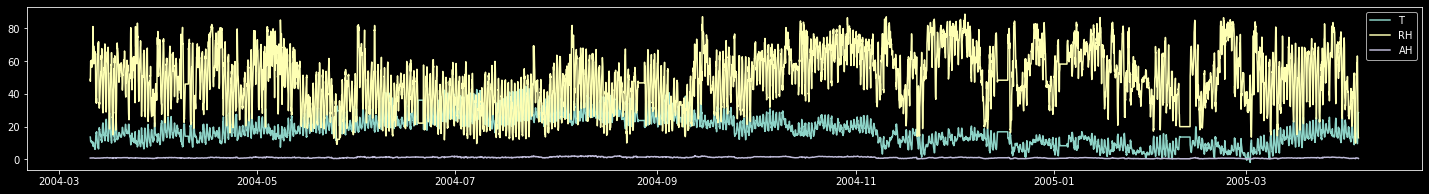

In [ ]:
# ▶ 2004-03 ~ 2005-03, 1년치 Data
# ▶ x, y data를 설정하여 Plotting
# import seaborn as sns
# import matplotlib.pyplot as plt
# %matplotlib inline
# plt.style.use(['dark_background'])

# plt.plot(df['Date_merge'], df['T'], label='T')
# plt.plot(df['Date_merge'], df['RH'], label='RH')
# plt.plot(df['Date_merge'], df['AH'], label='AH')

# plt.legend()
# plt.gcf().set_size_inches(25, 3)



import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['dark_background'])

plt.plot(df['Date_Merge'], df['T'], label='T')
plt.plot(df['Date_Merge'], df['RH'], label='RH')
plt.plot(df['Date_Merge'], df['AH'], label='AH')

plt.legend()
plt.gcf().set_size_inches(25, 3)

In [ ]:
# ▶ 화씨온도(℉) → 섭씨온도(℃)
# df['T'] = (df['T'] - 32) * 5/9

In [ ]:
# ▶ 섭씨온도(℃) → 화씨온도(℉)
# df['T'] = 9/5 * df['T'] + 32

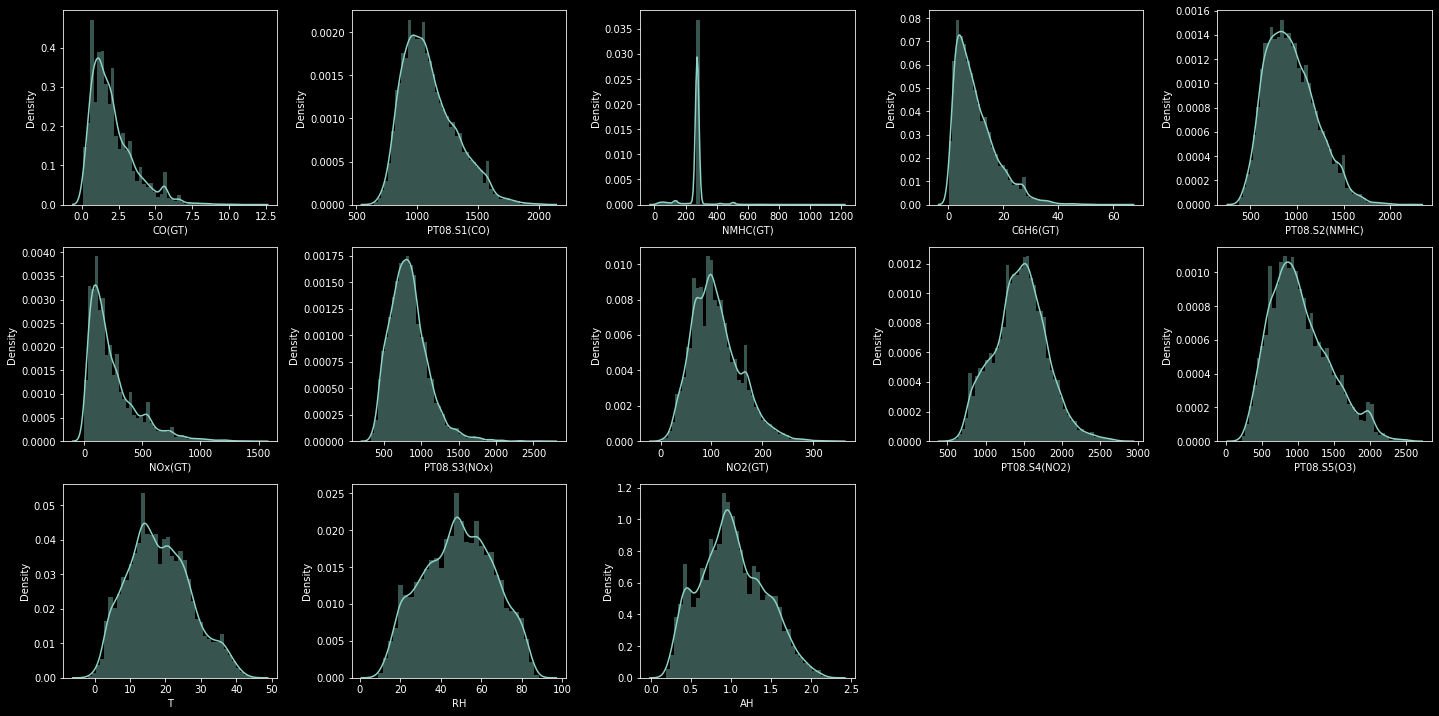

In [ ]:
# ▶ 모든 센서 데이터에 대해 분포를 확인

# for i in range(3,16):
#     plt.subplot(3,5,i-2)
#     plt.grid(False)
#     sns.distplot(df.iloc[:,i])

# plt.gcf().set_size_inches(20, 10)
# plt.tight_layout()
# plt.show();

for i in range(1,14):
    plt.subplot(3,5,i)
    plt.grid(False)
    sns.distplot(df.iloc[:,i+2])

plt.gcf().set_size_inches(20, 10)
plt.tight_layout()
plt.show();



### 정리
---
* fillna에 여러가지 기능이 있으니 찾아보는게 좋을것같다
* datatime merge 할때 중간에 띄어쓰기 해야 에러가 안생긴다